# 📊 Exploratory Data Analysis (EDA), Correlation & Regression Diagnostics Project

## Objective
Perform exploratory data analysis and build a linear regression model on the California Housing dataset, with full model diagnostics, error analysis, and business interpretation aligned with senior-level data analyst expectations.

## Dataset
Built-in California Housing dataset from Scikit-learn. No external files required.

## Skills Demonstrated
- EDA & statistical summaries
- Correlation & multicollinearity awareness
- Baseline model benchmarking
- Linear regression modeling
- Model evaluation (MAE, RMSE, R²)
- Residual diagnostics
- Feature importance interpretation
- Business insight storytelling


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline

## 1. Load Dataset

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 2. Exploratory Data Analysis

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


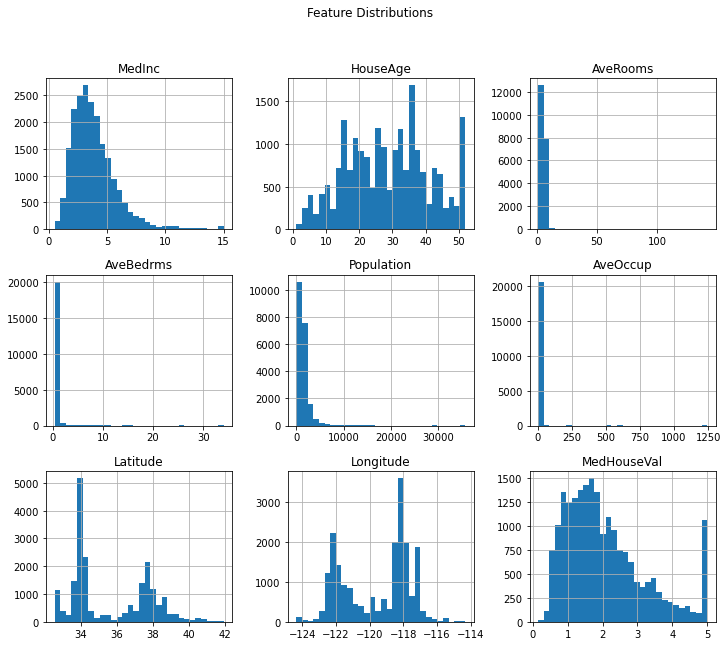

In [4]:
df.hist(figsize=(12,10), bins=30)
plt.suptitle('Feature Distributions')
plt.show()

## 3. Correlation Analysis

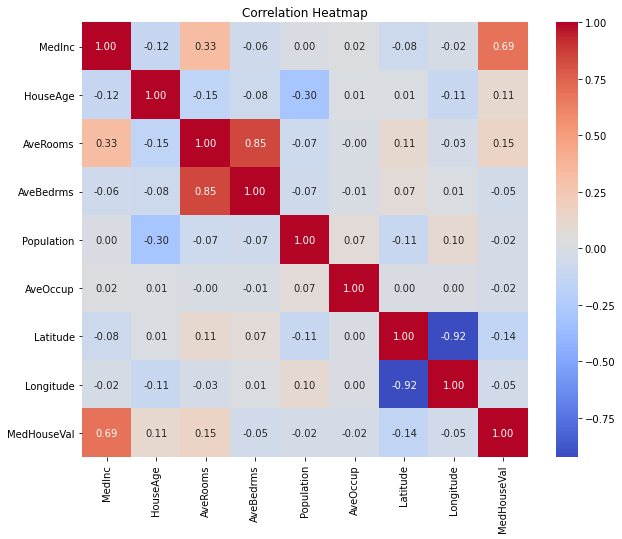

In [5]:
corr = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## 4. Baseline Model
Compare against a naive baseline to validate model value.

In [6]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

baseline_pred = np.full_like(y, y.mean())
baseline_mae = mean_absolute_error(y, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y, baseline_pred))

print(f'Baseline MAE: {baseline_mae:.3f}')
print(f'Baseline RMSE: {baseline_rmse:.3f}')

Baseline MAE: 0.912
Baseline RMSE: 1.154


## 5. Train/Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 6. Linear Regression Model

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)
preds = model.predict(X_test)

## 7. Model Evaluation

In [9]:
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f'MAE: {mae:.3f}')
print(f'RMSE: {rmse:.3f}')
print(f'R² Score: {r2:.3f}')

MAE: 0.533
RMSE: 0.746
R² Score: 0.576


## 8. Residual Analysis

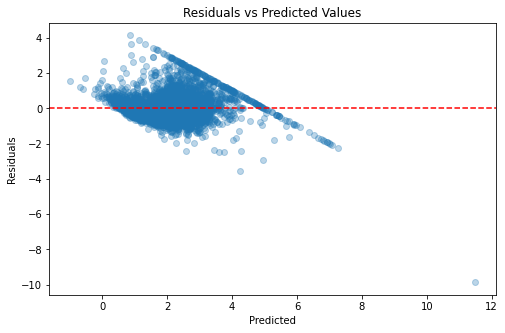

In [10]:
residuals = y_test - preds

plt.figure(figsize=(8,5))
plt.scatter(preds, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.show()

## 9. Feature Importance (Coefficient Interpretation)

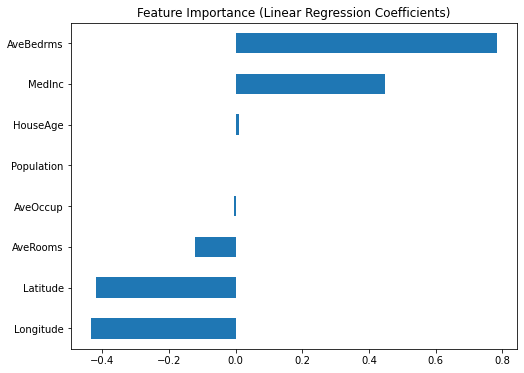

In [11]:
coef = pd.Series(model.coef_, index=X.columns).sort_values()
coef.plot(kind='barh', figsize=(8,6))
plt.title('Feature Importance (Linear Regression Coefficients)')
plt.show()

## 10. Cross-Validation (Model Robustness Check)

In [12]:
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print('Cross-Validation R² Scores:', cv_scores)
print('Mean CV R²:', cv_scores.mean())

Cross-Validation R² Scores: [0.54866323 0.46820691 0.55078434 0.53698703 0.66051406]
Mean CV R²: 0.5530311140279567


## 📌 Business Narrative

### Key Drivers of Housing Prices
Median income is the dominant predictor of housing value, indicating that affordability and local purchasing power are primary drivers of real estate pricing.

### Model Interpretation
The linear regression model performs significantly better than the baseline, confirming that structured economic variables carry predictive value. However, residual analysis shows non-linear patterns, suggesting that more complex models could improve accuracy.

### Business Implications
- Real estate pricing strategies should prioritize income-level segmentation
- Geographic clustering indicates localized market effects
- Model limitations suggest potential gains from non-linear approaches (e.g., Random Forest or Gradient Boosting)

### Insight
A key takeaway is not only model performance, but understanding where the model fails. Residual structure indicates missing non-linear relationships, which is critical for production-level forecasting systems.